In [4]:
#3-22 라이브러리 호출
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborInstance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
#명령어 해당 본문에 결과 바로 표출
%matplotlib inline

In [5]:
#3-23 weather.csv 파일 불러오기
dataset = pd.read_csv('./data/weather.csv')

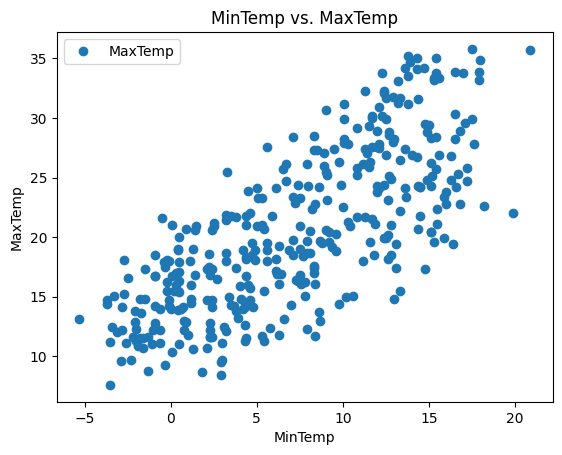

In [7]:
#3-24 데이터 간 관계를 시각화로 표현
dataset.plot(x='MinTemp', y='MaxTemp', style='o')
plt.title('MinTemp vs. MaxTemp')
#데이터 -> 속성(attribute)과 레이블(label)로 나뉨
#속성 : 독립 변수 / 레이블 : 종속 변수
# MinTemp에 따라 MaxTemp를 예측하기 위해 x변수는 MinTemp로 구성하고 y변수는 MaxTemp로 구성
plt.xlabel('MinTemp')
plt.ylabel('MaxTemp')
plt.show()

In [12]:
#3-25 데이터를 독립 변수와 종속 변수를 분리하고 선형 회귀 모델 생성
X = dataset['MinTemp'].values.reshape(-1, 1) #넘파일 배열로 만들고 세로 1줄짜리 행은 알아서 가공
y = dataset['MaxTemp'].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #데이터를 80%를 훈련 데이터셋으로 하고 데이터 20%를 검증 데이터 셋으로 분할

regressor = LinearRegression() #선형회귀 클래스 가져옴
regressor.fit(X_train, y_train) #fit() 메서드를 사용하여 모델 훈련


LinearRegression()

In [16]:
#3-26 회귀 모델에 대한 예측
y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual' : y_test.flatten(), 'Predicted' : y_pred.flatten()}) #실제 출력값과 예측 값
df

,Actual,Predicted
0,33.9,27.632288
1,23.1,21.842190
2,9.5,16.991027
3,14.3,17.460495
4,18.7,17.225761
...,...,...
69,14.5,15.660870
70,13.0,15.347892
71,14.2,14.643691
72,33.8,24.346016


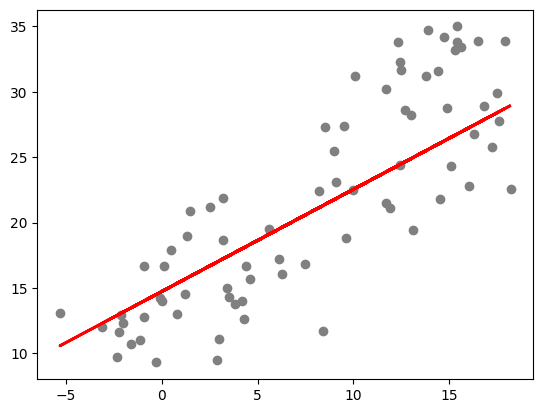

In [17]:
#3-27 테스트 데이터셋을 사용한 회귀선 표현
plt.scatter(X_test, y_test, color='gray')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.show()

In [25]:
#3-28 선형 회귀 모델 평가
print('백분율 평균:', dataset['MaxTemp'].mean())
print('평균제곱법:', metrics.mean_squared_error(y_test, y_pred))
print('루트 평균제곱법:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

#루트평균제곱법(root mean squared) : 평균제곱법(mean squared)에 루트를 씌운 것 
#(해석) 20도 정도 평균인데 매번 4.5 온도 오차가 있다 -> 4.5 / 20.5 = 20%

백분율 평균: 20.550273224043714
평균제곱법: 20.663853965685544
루트 평균제곱법: 4.545751199272299
